In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("titanic_toy.csv")

In [5]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [8]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
x = df.drop(columns=["Survived"])
y = df["Survived"]

In [12]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [13]:
X_train.shape

(712, 3)

In [14]:
X_test.shape

(179, 3)

In [15]:
X_train.isnull().mean()

Age       0.198034
Fare      0.054775
Family    0.000000
dtype: float64

In [16]:
mean_age = X_train["Age"].mean()
median_age = X_train["Age"].median()

mean_fare = X_train["Fare"].mean()
median_fare = X_train["Fare"].median()

In [17]:
mean_age

np.float64(29.745183887915935)

In [18]:
median_fare

14.4542

In [19]:
X_train["Age_median"] = X_train["Age"].fillna(median_age)
X_train["Age_mean"] = X_train["Age"].fillna(mean_age)

X_train["Fare_median"] = X_train["Fare"].fillna(median_fare)
X_train["Fare_mean"] = X_train["Fare"].fillna(mean_fare)

In [20]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
388,NaN,7.7292,0,29.0,29.745184,7.7292,7.7292
256,NaN,79.2000,0,29.0,29.745184,79.2000,79.2000
685,25.0,41.5792,3,25.0,25.000000,41.5792,41.5792
296,23.5,7.2292,0,23.5,23.500000,7.2292,7.2292
684,60.0,39.0000,2,60.0,60.000000,39.0000,39.0000


In [21]:
print("Orginal Varience of Age ",X_train["Age"].var())
print("Age Varience of after median imputation ",X_train["Age_median"].var())
print("Age Varience of after mean imputation ",X_train["Age_mean"].var())

Orginal Varience of Age  213.7165085187578
Age Varience of after median imputation  171.42222438960798
Age Varience of after mean imputation  171.33390978297038


In [22]:
print("Orginal Varience of Fare ",X_train["Fare"].var())
print("Fare Varience of after median imputation ",X_train["Fare_median"].var())
print("Fare Varience of after mean imputation ",X_train["Fare_mean"].var())

Orginal Varience of Fare  2574.3526206637193
Fare Varience of after median imputation  2448.897024777755
Fare Varience of after mean imputation  2433.143405184275


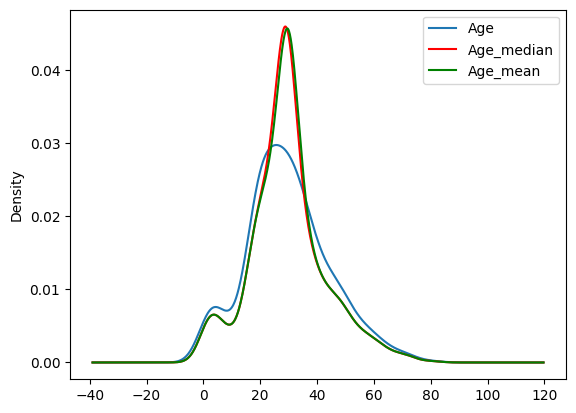

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

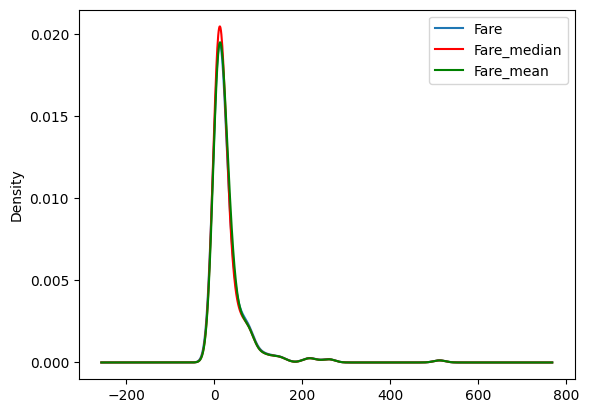

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [25]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,213.716509,84.480223,-6.393469,213.716509,213.716509,79.420930,79.571049
Fare,84.480223,2574.352621,17.050423,68.754981,67.493301,2574.352621,2574.352621
Family,-6.393469,17.050423,2.770177,-5.121468,-5.125566,16.285129,16.115167
Age_median,213.716509,68.754981,-5.121468,171.422224,171.333910,64.831778,64.983611
Age_mean,213.716509,67.493301,-5.125566,171.333910,171.333910,63.670788,63.791137
Fare_median,79.420930,2574.352621,16.285129,64.831778,63.670788,2448.897025,2433.143405
Fare_mean,79.571049,2574.352621,16.115167,64.983611,63.791137,2433.143405,2433.143405


In [26]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.106334,-0.295318,1.000000,1.000000,0.103346,0.103929
Fare,0.106334,1.000000,0.198661,0.102921,0.101058,1.000000,1.000000
Family,-0.295318,0.198661,1.000000,-0.235021,-0.235270,0.197721,0.196290
Age_median,1.000000,0.102921,-0.235021,1.000000,0.999742,0.100062,0.100620
Age_mean,1.000000,0.101058,-0.235270,0.999742,1.000000,0.098295,0.098800
Fare_median,0.103346,1.000000,0.197721,0.100062,0.098295,1.000000,0.996778
Fare_mean,0.103929,1.000000,0.196290,0.100620,0.098800,0.996778,1.000000


<Axes: >

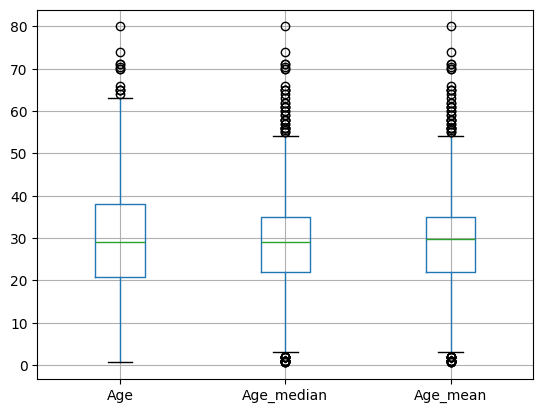

In [28]:
X_train[["Age","Age_median","Age_mean"]].boxplot()

<Axes: >

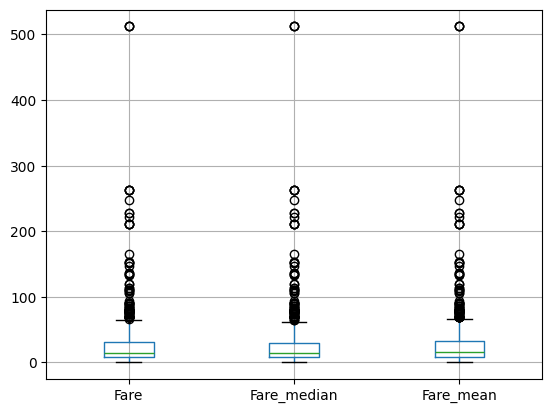

In [29]:
X_train[["Fare","Fare_median","Fare_mean"]].boxplot()

<h1>Using Scikit Learn</h1>

In [30]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=2)

In [31]:
X_train.shape

(623, 3)

In [32]:
imputer1 = SimpleImputer(strategy="median")
imputer2 = SimpleImputer(strategy="mean")

In [39]:
trf = ColumnTransformer([
    
    ("imputer1",imputer1,["Age"]),
    ("imputer2",imputer2,["Fare"])
    
    ],remainder="passthrough"
)

In [40]:
trf

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [41]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [43]:
trf.named_transformers_["imputer1"].statistics_

array([28.])

In [45]:
trf.named_transformers_["imputer2"].statistics_

array([32.66688571])

In [46]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [47]:
X_train

array([[ 28.    ,  19.9667,   1.    ],
       [ 24.    ,  13.    ,   0.    ],
       [ 19.    ,  10.1708,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.    , 221.7792,   0.    ],
       [ 28.    ,  25.925 ,   0.    ]], shape=(623, 3))

In [48]:
X_test

array([[ 42.        ,  26.2875    ,   0.        ],
       [ 21.        ,   8.05      ,   0.        ],
       [ 24.        ,  65.        ,   3.        ],
       [ 28.        ,  56.4958    ,   0.        ],
       [ 17.        ,   7.925     ,   6.        ],
       [ 30.        ,   7.8958    ,   0.        ],
       [ 80.        ,  30.        ,   0.        ],
       [ 25.        ,   7.25      ,   0.        ],
       [ 50.        , 133.65      ,   2.        ],
       [ 25.        ,  26.        ,   1.        ],
       [ 35.        ,  26.        ,   0.        ],
       [ 35.        ,  90.        ,   1.        ],
       [ 55.        ,  16.        ,   0.        ],
       [ 28.        ,  56.4958    ,   0.        ],
       [ 28.        ,  56.4958    ,   0.        ],
       [ 19.        ,   7.8542    ,   1.        ],
       [ 28.        ,  15.2458    ,   2.        ],
       [ 49.        ,   0.        ,   0.        ],
       [ 18.        ,  32.66688571,   1.        ],
       [ 65.        ,   7.75   